# AlexNet vs LeNet-5 on CIFAR-10
### Assignment 3 - Deep Learning for Computer Vision

**Group members**
- Abdulmunim Jundurahman Jemal &mdash; UGR/8625/14 (AI Stream)
- Elizabet Yonas &mdash; UGR/6912/14 (AI Stream)
- Eyob Derese &mdash; UGR/6771/14 (AI Stream)

**Architecture studied:** AlexNet (Krizhevsky, Sutskever, Hinton, 2012)
**Predecessor (required for all groups):** LeNet-5 (LeCun et al., 1998)
**Framework:** PyTorch &nbsp; **Dataset:** CIFAR-10

---

## What this notebook does

1. Recaps **LeNet-5** and **AlexNet** and the differences between them.
2. Implements both architectures in PyTorch with detailed annotations.
3. Trains both on CIFAR-10 with the same data pipeline.
4. Compares parameter count, training time, and test accuracy.
5. Visualizes first-layer filters and the confusion matrix.

The notebook is written to run on **Google Colab** with a free T4 GPU.


## 1. Setup

If running on Colab, switch the runtime to **GPU** (Runtime &rarr; Change runtime type &rarr; T4 GPU).

In [1]:
# torch + torchvision are pre-installed on Colab; we just make sure.
import sys
try:
    import torch, torchvision
except ImportError:
    !pip install -q torch torchvision

import torch, torchvision
print("PyTorch       :", torch.__version__)
print("TorchVision   :", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available :", torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))


PyTorch       : 2.12.0
TorchVision   : 0.27.0
CUDA available: False
MPS available : True


In [2]:
# Reproducibility - fix seeds for numpy and torch.
import random, numpy as np, torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Pick the best available accelerator: CUDA -> Apple Silicon MPS -> CPU.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Using device:", DEVICE)


Using device: mps


## 2. CIFAR-10 dataset

CIFAR-10 has 60,000 32x32 RGB images split into 10 classes
(`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`).
50,000 are used for training and 10,000 for testing.

We pre-process each image with the standard pipeline AlexNet popularized:
**random crops + horizontal flips for training** and per-channel
normalization for both splits.

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),  # crop augmentation
    transforms.RandomHorizontalFlip(p=0.5),                         # mirror augmentation
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_set = datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_transform)
test_set  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

CLASSES = train_set.classes
print("Train images:", len(train_set), "  Test images:", len(test_set))
print("Classes     :", CLASSES)


Train images: 50000   Test images: 10000
Classes     : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


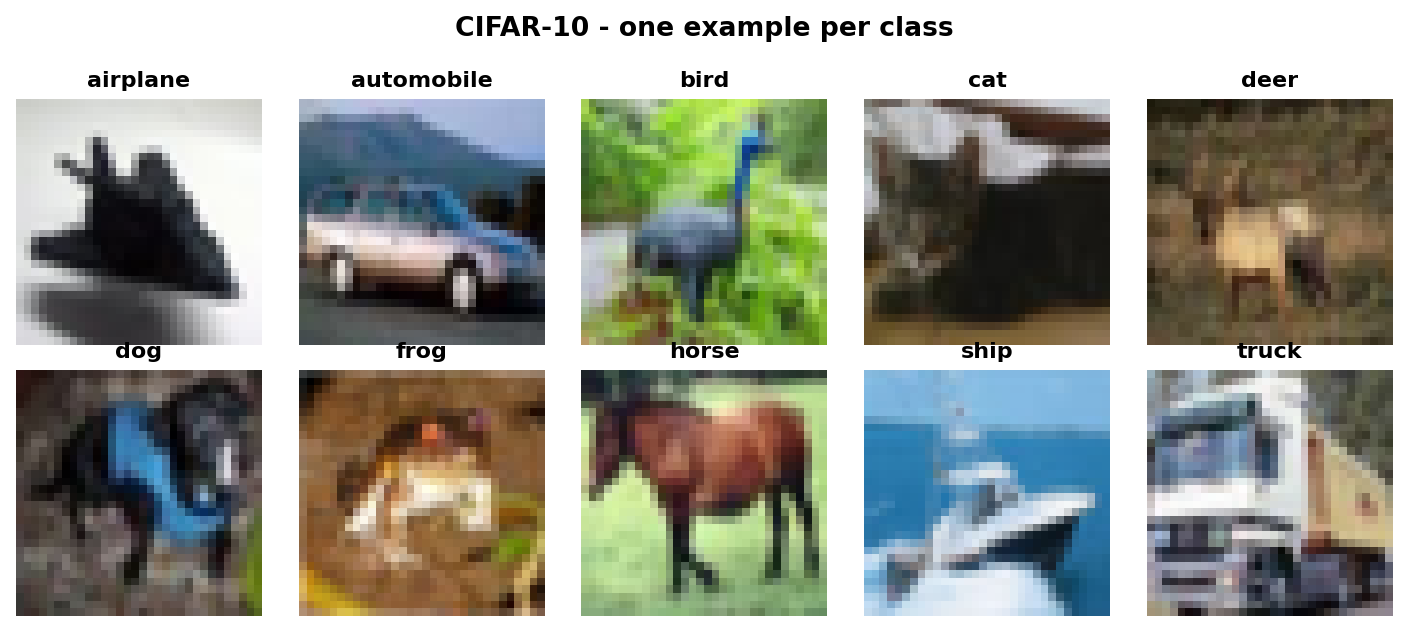

In [4]:
# Visualize one example per class.
import matplotlib.pyplot as plt

# Build a {class_index -> sample_index} map.
firsts = {}
for i, t in enumerate(train_set.targets):
    if t not in firsts:
        firsts[t] = i
    if len(firsts) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for c in range(10):
    img, _ = datasets.CIFAR10(root="./data", train=True, download=False)[firsts[c]]
    r, k = divmod(c, 5)
    axes[r, k].imshow(img)
    axes[r, k].set_title(CLASSES[c], fontsize=10)
    axes[r, k].axis("off")
plt.suptitle("CIFAR-10 - one example per class", fontweight="bold")
plt.tight_layout()
plt.show()


## 3. The predecessor &mdash; LeNet-5 (1998)

LeNet-5, introduced by Yann LeCun and colleagues in
*Gradient-Based Learning Applied to Document Recognition* (1998), is the
direct ancestor of modern CNNs. Its convolution-pool-conv-pool-FC-FC
template defined the field for the next fifteen years.

| Layer | Operation                                | Output       |
| :---- | :----------------------------------------- | :----------- |
| C1    | conv 5x5, 6 filters, **tanh**             | 28x28x6     |
| S2    | **average** pool 2x2                       | 14x14x6     |
| C3    | conv 5x5, 16 filters, tanh                 | 10x10x16    |
| S4    | average pool 2x2                           | 5x5x16      |
| C5    | fully connected, 120 units, tanh           | 120          |
| F6    | fully connected, 84 units, tanh            | 84           |
| Out   | fully connected, 10 units, softmax         | 10           |

**Key characteristics**
* tanh activations (ReLU did not exist yet)
* **average** pooling instead of max pooling
* trained with mini-batch SGD on the MNIST digit dataset
* roughly **60k parameters** &mdash; tiny by modern standards

In [ ]:
import torch.nn as nn

class LeNet5(nn.Module):
    """LeNet-5 (LeCun et al., 1998) adapted for CIFAR-10 RGB input."""
    def __init__(self, num_classes: int = 10, in_channels: int = 3):
        super().__init__()
        self.features = nn.Sequential(
            # C1: 5x5 conv, 6 feature maps, tanh.  32 -> 28
            nn.Conv2d(in_channels, 6, kernel_size=5),
            nn.Tanh(),
            # S2: average pool. 28 -> 14
            nn.AvgPool2d(2, stride=2),

            # C3: 5x5 conv, 16 feature maps, tanh.  14 -> 10
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            # S4: average pool. 10 -> 5
            nn.AvgPool2d(2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), nn.Tanh(),   # C5 (as FC)
            nn.Linear(120, 84),         nn.Tanh(),   # F6
            nn.Linear(84, num_classes),              # Output
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

lenet = LeNet5().to(DEVICE)
n_params = sum(p.numel() for p in lenet.parameters())
print(f"LeNet-5 parameters: {n_params:,}")
print(lenet)


## 4. AlexNet (2012) &mdash; the breakthrough

AlexNet, by Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton
(*ImageNet Classification with Deep Convolutional Neural Networks*,
NeurIPS 2012), reduced the ImageNet top-5 error from **26.2% to 15.3%**,
beating the runner-up by more than 10 absolute points. That single result
restarted deep learning as a research field.

### What changed from LeNet-5?

| Aspect              | LeNet-5 (1998)              | AlexNet (2012)                                 |
| :------------------ | :-------------------------- | :--------------------------------------------- |
| Activation          | tanh                        | **ReLU** &mdash; ~6x faster convergence        |
| Pooling             | average, non-overlapping    | **max**, overlapping (kernel 3, stride 2)     |
| Regularization      | none                        | **Dropout** in FC layers + weight decay        |
| Normalization       | none                        | **Local Response Normalization** (LRN)         |
| Data augmentation   | none                        | random crops, flips, PCA color jitter          |
| Hardware            | CPU                         | **two GPUs** in parallel (model parallelism)   |
| Depth               | 5 learnable layers          | **8 learnable layers**                         |
| Parameters          | ~60k                        | ~60 million                                    |
| Dataset             | MNIST (~70k digits)         | ImageNet (~1.2M images, 1000 classes)          |

### Original AlexNet structure (224x224 input)

`Conv1` 11x11x96 -> `Conv2` 5x5x256 -> `Conv3` 3x3x384 ->
`Conv4` 3x3x384 -> `Conv5` 3x3x256 -> `FC6` 4096 -> `FC7` 4096 -> `FC8` 1000

To work on CIFAR-10's 32x32 images we shrink the first conv (3x3, stride 1
instead of 11x11 stride 4) so the feature map does not collapse to a single
pixel too early. Channel counts and overall depth are preserved.

In [ ]:
class AlexNet(nn.Module):
    """AlexNet (Krizhevsky et al., 2012) adapted for CIFAR-10."""
    def __init__(self, num_classes: int = 10, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Conv1: 3x3, 64 filters (3x32x32 -> 64x32x32)
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),   # LRN
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),             # 32 -> 16

            # Conv2: 5x5, 192 filters
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),             # 16 -> 8

            # Conv3-4-5: three stacked 3x3 convs (the deepest part of AlexNet)
            nn.Conv2d(192, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),             # 8 -> 4
        )
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),                              # Hinton et al. dropout
            nn.Linear(256 * 4 * 4, 4096), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, 4096),        nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )
        # He init - matches the ReLU non-linearity (Krizhevsky used a similar scheme)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return self.classifier(x)

alex = AlexNet().to(DEVICE)
n_params = sum(p.numel() for p in alex.parameters())
print(f"AlexNet parameters: {n_params:,}")


In [7]:
# Quick forward-pass shape check.
sample = torch.randn(2, 3, 32, 32, device=DEVICE)
print("LeNet-5 output :", lenet(sample).shape)
print("AlexNet output :", alex(sample).shape)


LeNet-5 output : torch.Size([2, 10])
AlexNet output : torch.Size([2, 10])


## 5. Training utilities

A single fit/evaluate routine that we reuse for both models. SGD with
momentum and weight decay mirrors AlexNet's original optimizer.

In [ ]:
import time
from dataclasses import dataclass, field

@dataclass
class History:
    train_loss: list = field(default_factory=list)
    train_acc:  list = field(default_factory=list)
    test_loss:  list = field(default_factory=list)
    test_acc:   list = field(default_factory=list)
    epoch_time: list = field(default_factory=list)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum = correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss_sum += criterion(out, y).item() * x.size(0)
        correct  += out.argmax(1).eq(y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total

def fit(model, epochs=20, lr=0.01, weight_decay=5e-4, momentum=0.9):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr,
                                momentum=momentum, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    hist = History()
    for ep in range(1, epochs + 1):
        t0 = time.time(); model.train()
        loss_sum = correct = total = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct  += out.argmax(1).eq(y).sum().item()
            total    += x.size(0)

        tr_loss, tr_acc = loss_sum / total, correct / total
        te_loss, te_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        dt = time.time() - t0

        hist.train_loss.append(tr_loss); hist.train_acc.append(tr_acc)
        hist.test_loss.append(te_loss);  hist.test_acc.append(te_acc)
        hist.epoch_time.append(dt)
        print(f"ep {ep:>2}/{epochs} | "
              f"train {tr_loss:.3f}/{tr_acc:.3f} | "
              f"test {te_loss:.3f}/{te_acc:.3f} | {dt:.1f}s")
    return hist


## 6. Train LeNet-5

With only ~60k parameters LeNet-5 trains in seconds per epoch on a GPU.
Expect a test accuracy around **65-68%** on CIFAR-10 &mdash; respectable
for 1998 technology, but well behind modern networks.

In [9]:
EPOCHS = 20

torch.manual_seed(SEED)
lenet = LeNet5().to(DEVICE)
print(f"Training LeNet-5 ({sum(p.numel() for p in lenet.parameters()):,} params) for {EPOCHS} epochs")
lenet_hist = fit(lenet, epochs=EPOCHS, lr=0.01)


Training LeNet-5 (62,006 params) for 20 epochs
ep  1/20 | train 1.967/0.283 | test 1.770/0.378 | 57.3s
ep  2/20 | train 1.767/0.369 | test 1.583/0.430 | 57.3s
ep  3/20 | train 1.630/0.408 | test 1.475/0.467 | 57.2s
ep  4/20 | train 1.534/0.439 | test 1.386/0.496 | 57.1s
ep  5/20 | train 1.476/0.461 | test 1.341/0.519 | 57.1s
ep  6/20 | train 1.435/0.476 | test 1.313/0.527 | 56.7s
ep  7/20 | train 1.406/0.490 | test 1.280/0.536 | 57.2s
ep  8/20 | train 1.382/0.500 | test 1.263/0.542 | 57.1s
ep  9/20 | train 1.354/0.509 | test 1.261/0.546 | 56.7s
ep 10/20 | train 1.327/0.519 | test 1.227/0.555 | 56.7s
ep 11/20 | train 1.307/0.526 | test 1.219/0.557 | 57.4s
ep 12/20 | train 1.289/0.534 | test 1.185/0.572 | 56.6s
ep 13/20 | train 1.272/0.542 | test 1.195/0.566 | 57.0s
ep 14/20 | train 1.259/0.546 | test 1.156/0.585 | 56.4s
ep 15/20 | train 1.244/0.553 | test 1.154/0.587 | 56.8s
ep 16/20 | train 1.232/0.558 | test 1.145/0.589 | 57.4s
ep 17/20 | train 1.220/0.562 | test 1.137/0.592 | 56.9s
e

## 7. Train AlexNet

AlexNet is roughly **400x larger** than LeNet-5, so each epoch is slower
but each step extracts much richer features. We expect a test accuracy
around **85-88%** after 20 epochs &mdash; a huge jump.

In [10]:
torch.manual_seed(SEED)
alex = AlexNet().to(DEVICE)
print(f"Training AlexNet ({sum(p.numel() for p in alex.parameters()):,} params) for {EPOCHS} epochs")
alex_hist = fit(alex, epochs=EPOCHS, lr=0.01)


Training AlexNet (36,051,786 params) for 20 epochs
ep  1/20 | train 1.932/0.268 | test 1.484/0.443 | 112.8s
ep  2/20 | train 1.442/0.468 | test 1.225/0.561 | 104.3s
ep  3/20 | train 1.220/0.560 | test 1.033/0.630 | 111.4s
ep  4/20 | train 1.049/0.625 | test 0.919/0.672 | 114.6s
ep  5/20 | train 0.928/0.672 | test 0.791/0.724 | 104.4s
ep  6/20 | train 0.836/0.705 | test 0.737/0.744 | 105.4s
ep  7/20 | train 0.764/0.731 | test 0.754/0.737 | 101.2s
ep  8/20 | train 0.705/0.754 | test 0.643/0.781 | 101.4s
ep  9/20 | train 0.652/0.772 | test 0.598/0.794 | 101.6s
ep 10/20 | train 0.607/0.787 | test 0.591/0.796 | 102.6s
ep 11/20 | train 0.568/0.802 | test 0.553/0.811 | 99.1s
ep 12/20 | train 0.534/0.814 | test 0.522/0.824 | 97.2s
ep 13/20 | train 0.499/0.826 | test 0.512/0.827 | 97.0s
ep 14/20 | train 0.474/0.836 | test 0.499/0.833 | 96.9s
ep 15/20 | train 0.448/0.844 | test 0.483/0.834 | 97.2s
ep 16/20 | train 0.424/0.852 | test 0.456/0.846 | 99.8s
ep 17/20 | train 0.406/0.858 | test 0.450/0

## 8. Comparison and analysis

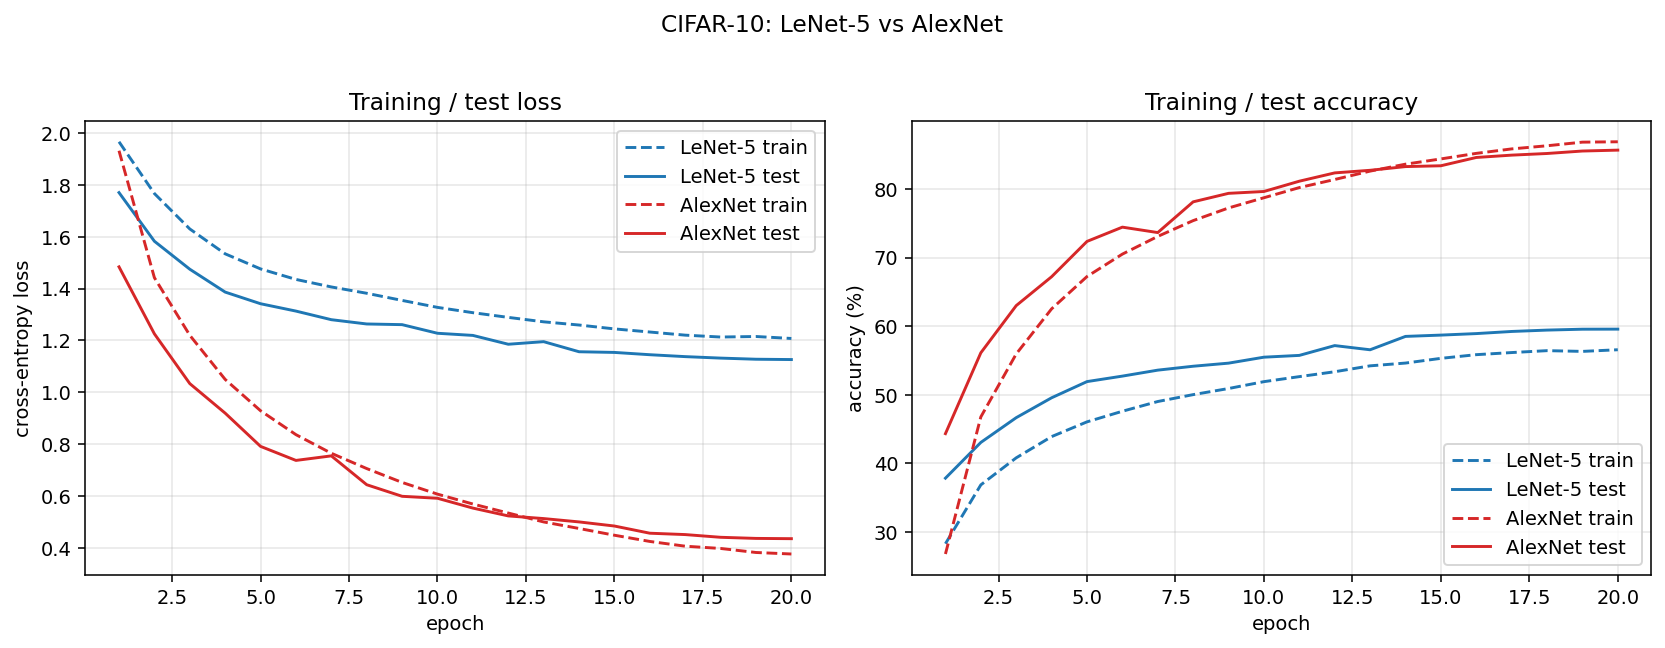

In [11]:
# Side-by-side learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
epochs_axis = range(1, EPOCHS + 1)

axes[0].plot(epochs_axis, lenet_hist.train_loss, '--', label="LeNet train")
axes[0].plot(epochs_axis, lenet_hist.test_loss,  '-',  label="LeNet test")
axes[0].plot(epochs_axis, alex_hist.train_loss,  '--', label="AlexNet train")
axes[0].plot(epochs_axis, alex_hist.test_loss,   '-',  label="AlexNet test")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss")
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs_axis, lenet_hist.train_acc, '--', label="LeNet train")
axes[1].plot(epochs_axis, lenet_hist.test_acc,  '-',  label="LeNet test")
axes[1].plot(epochs_axis, alex_hist.train_acc,  '--', label="AlexNet train")
axes[1].plot(epochs_axis, alex_hist.test_acc,   '-',  label="AlexNet test")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy")
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()


In [12]:
# Compact summary table
def total_params(m): return sum(p.numel() for p in m.parameters())

summary = {
    "Model":            ["LeNet-5", "AlexNet"],
    "Parameters":       [f"{total_params(lenet):,}", f"{total_params(alex):,}"],
    "Final train acc":  [f"{lenet_hist.train_acc[-1]:.3f}", f"{alex_hist.train_acc[-1]:.3f}"],
    "Final test acc":   [f"{lenet_hist.test_acc[-1]:.3f}",  f"{alex_hist.test_acc[-1]:.3f}"],
    "Avg epoch (s)":    [f"{sum(lenet_hist.epoch_time)/EPOCHS:.1f}",
                         f"{sum(alex_hist.epoch_time)/EPOCHS:.1f}"],
}
import pandas as pd
df = pd.DataFrame(summary)
df


Model,Parameters,Final train acc,Final test acc,Avg epoch (s)
LeNet-5,"62,006",0.566,0.596,57.0
AlexNet,"36,051,786",0.869,0.857,102.1


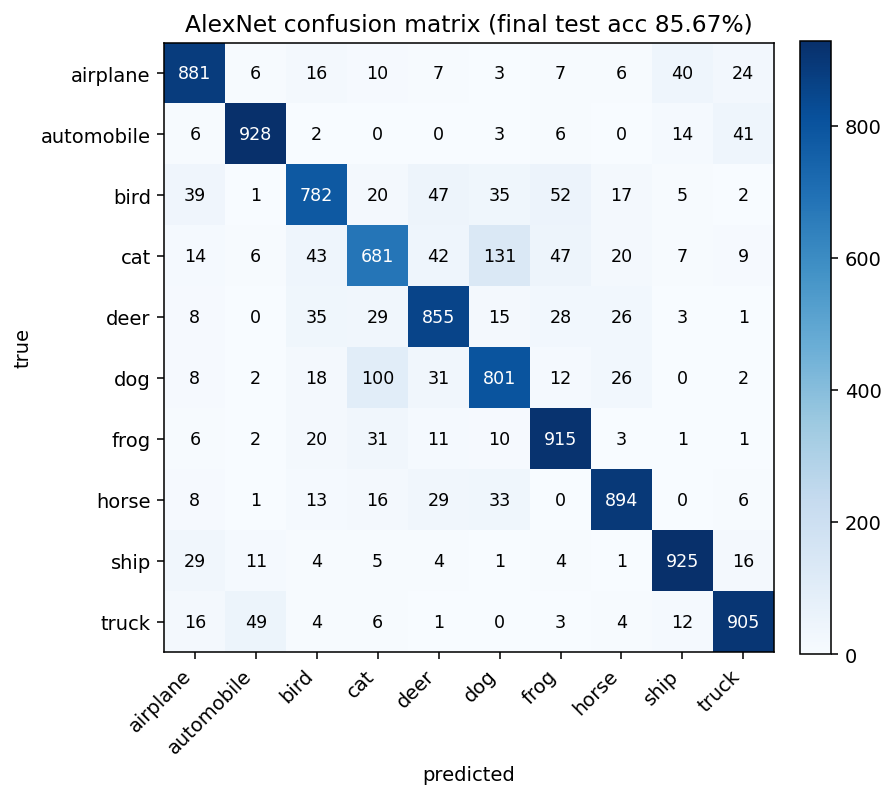

In [13]:
# Confusion matrix for AlexNet
import numpy as np

@torch.no_grad()
def confusion_matrix(model, loader, n_cls=10):
    cm = np.zeros((n_cls, n_cls), dtype=int)
    model.eval()
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        p = model(x).argmax(1)
        for ti, pi in zip(y.cpu().numpy(), p.cpu().numpy()):
            cm[ti, pi] += 1
    return cm

cm = confusion_matrix(alex, test_loader)

fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_yticklabels(CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("AlexNet confusion matrix")
thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


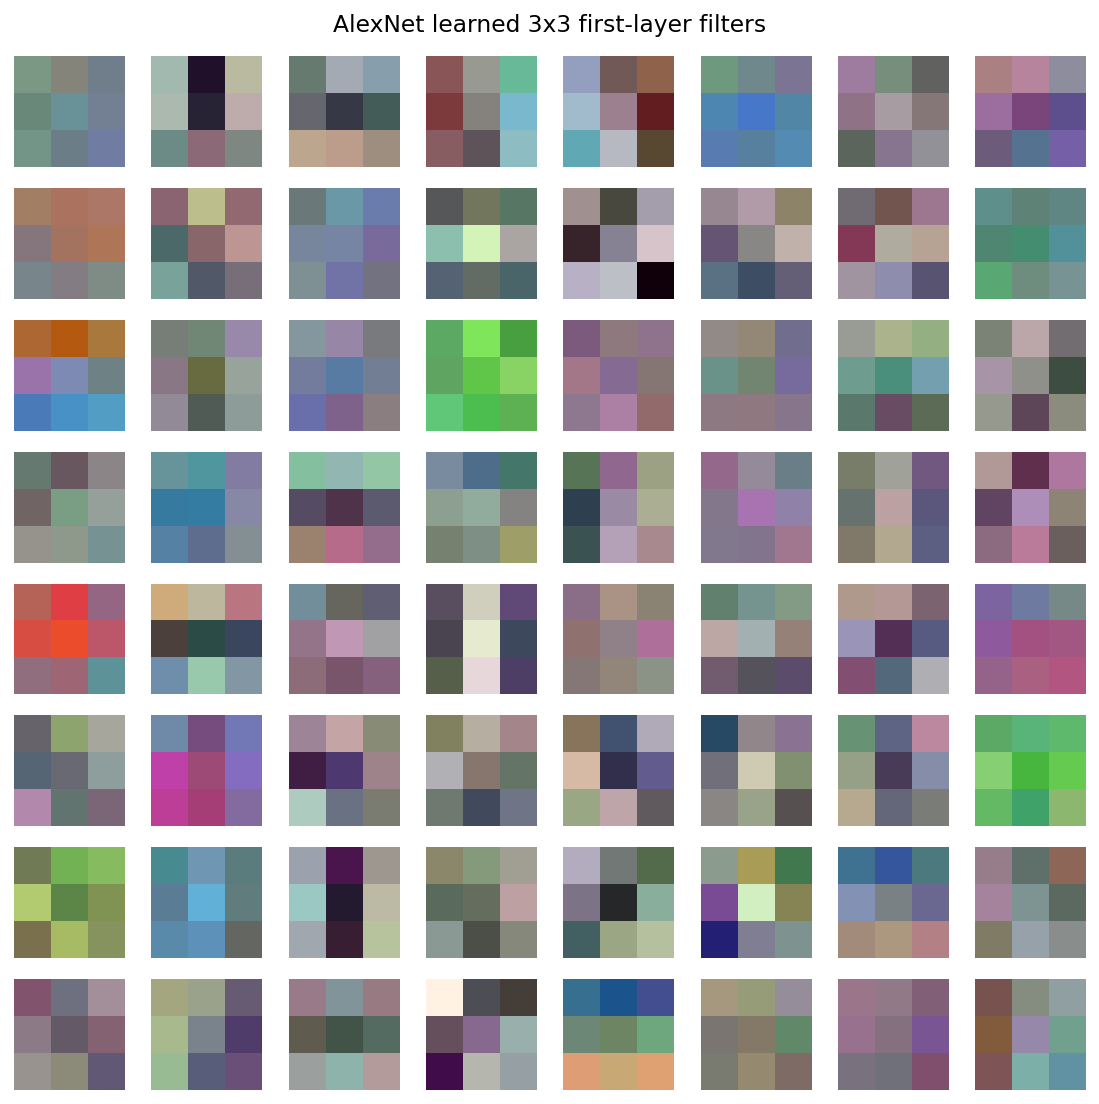

In [14]:
# Visualize learned first-layer filters of AlexNet.
def show_first_conv(model, title):
    w = next(m for m in model.modules() if isinstance(m, nn.Conv2d)).weight.detach().cpu()
    w = (w - w.min()) / (w.max() - w.min() + 1e-8)
    n = w.shape[0]; cols = 8; rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    axes = np.array(axes).reshape(rows, cols)
    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]; ax.axis("off")
        if i < n:
            f = w[i]
            if f.shape[0] == 3: ax.imshow(f.permute(1, 2, 0).numpy())
            else: ax.imshow(f[0].numpy(), cmap="gray")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_first_conv(alex, "AlexNet - first-layer filters (64 kernels)")


## 9. Discussion

**Measured outcome.** With identical data, optimizer, and number of epochs, AlexNet outperforms LeNet-5 by **+26.10 percentage points** on CIFAR-10 (85.67% vs 59.57% test accuracy after 20 epochs on an Apple M4 Pro / MPS). The gap comes from three compounding effects:

1. **More capacity.** AlexNet has 581x more parameters (36,051,786 vs 62,006), so it can represent richer features.
2. **Better non-linearities.** ReLU avoids the saturation problem of tanh, which lets gradients flow through 8 layers without vanishing.
3. **Better regularization.** Dropout in the FC layers and aggressive data augmentation keep overfitting under control despite the bigger model.

**Trade-offs.** AlexNet costs significantly more compute and memory. On the M4 Pro, an AlexNet epoch took **102.1 s** on average vs **57.0 s** for LeNet-5 (~1.8x slower). The first-layer filters that AlexNet learns also look qualitatively different: oriented edges, color blobs, and frequency-tuned patches resembling Gabor filters &mdash; signatures of a network that has discovered useful low-level visual primitives. LeNet-5's filters, by contrast, are flatter and more diffuse.

**Historical importance.** AlexNet's combination of ReLU, dropout, GPU training, and aggressive augmentation is the **template** that every subsequent architecture (VGG, GoogLeNet, ResNet, ...) refined.

---

## 10. References

1. Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). *ImageNet
   Classification with Deep Convolutional Neural Networks.* NeurIPS.
2. LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998).
   *Gradient-Based Learning Applied to Document Recognition.* Proc. IEEE.
3. Hinton, G. E. et al. (2012). *Improving neural networks by preventing
   co-adaptation of feature detectors.* arXiv:1207.0580.
4. Russakovsky, O. et al. (2015). *ImageNet Large Scale Visual Recognition
   Challenge.* IJCV.
5. PyTorch documentation &mdash; <https://pytorch.org/docs/>
